In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('Weather Data.csv')
df

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [4]:
df.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [5]:

df.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [6]:
df.columns = df.columns.str.strip()
df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["Year"] = df["Date/Time"].dt.year
df["Month"] = df["Date/Time"].dt.month
df["Day"] = df["Date/Time"].dt.day
df["Hour"] = df["Date/Time"].dt.hour

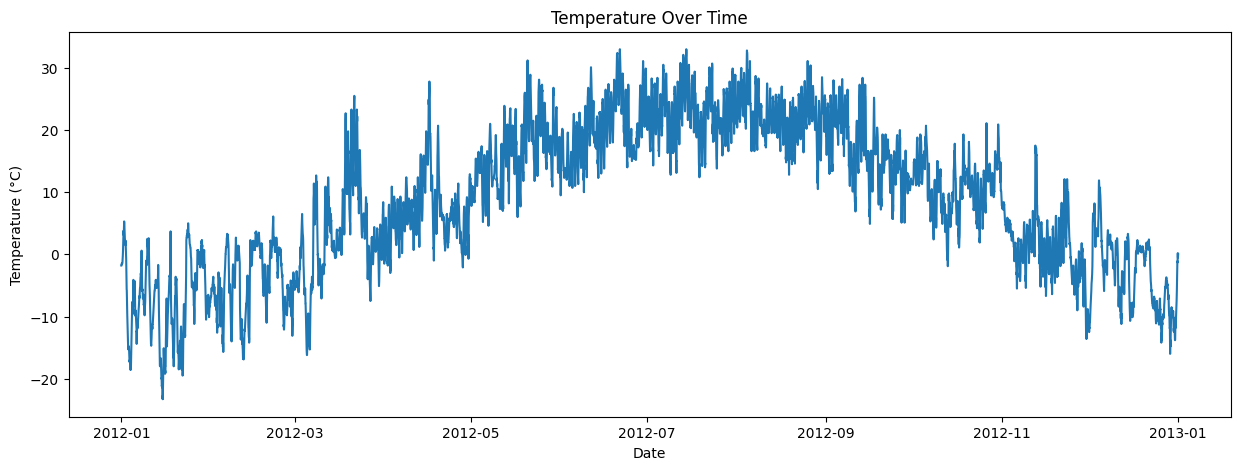

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df["Date/Time"], df["Temp_C"])
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

In [8]:
corr = df.corr(numeric_only=True)

print(corr["Temp_C"].sort_values(ascending=False))

Temp_C              1.000000
Dew Point Temp_C    0.932714
Visibility_km       0.273455
Month               0.218048
Hour                0.106888
Day                 0.009300
Wind Speed_km/h    -0.061876
Rel Hum_%          -0.220182
Press_kPa          -0.236389
Year                     NaN
Name: Temp_C, dtype: float64


In [9]:
df = df.drop(columns=["Date/Time","Weather"])

In [10]:
X = df.drop("Temp_C", axis=1)

y = df["Temp_C"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
pred = model.predict(X_test)


In [14]:
print("MAE:", mean_absolute_error(y_test, pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

print("R2 Score:", r2_score(y_test, pred))

MAE: 0.6058381362984646
RMSE: 0.8206888056162076
R2 Score: 0.9953493096159481


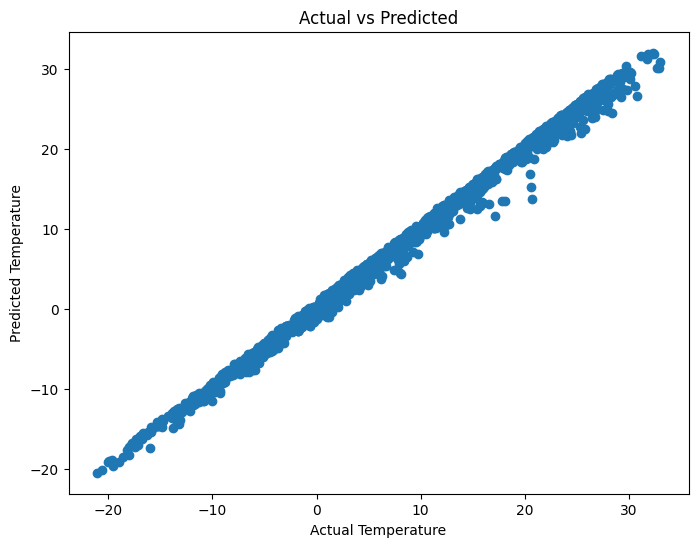

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted")

plt.show()

In [16]:
sample = [[
    45.0,    # Dew Point Temp_C (extremely high)
    90,      # Relative Humidity
    5,       # Wind Speed (km/h)
    30,      # Visibility (km)
    99.5,    # Pressure (kPa)
    2012,    # Year
    6,       # Month
    15,      # Day
    14       # Hour
]]

predicted_temp = model.predict(sample)
print(predicted_temp[0])

47.89144483075717


c:\Users\kesha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
import pickle

pickle.dump(model, open("weather_model.pkl", "wb"))